In [19]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)

2.21.0


In [20]:
observations=10000
xs = np.random.uniform(low=-10, high=10, size=(observations,1))
zs = np.random.uniform(low=-10, high=10, size=(observations,1))
inputs=np.column_stack((xs,zs))
print(inputs.shape)

(10000, 2)


In [21]:
noise = np.random.uniform(low=-1,high=1, size=(observations,1))
targets = 10*xs - 15*zs + 20 + noise
np.savez('TF_dataset', inputs=inputs, targets=targets)
print(targets.shape)

(10000, 1)


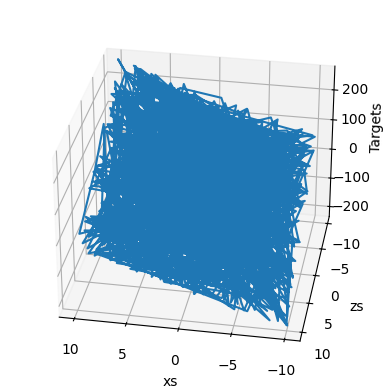

In [12]:
targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs, zs, targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('Targets')
ax.view_init(azim=100)
plt.show()

In [13]:
init_range = 0.1
weights = np.random.uniform(low=-init_range,high=init_range,size=(2,1))
biases = np.random.uniform(low=-init_range,high=init_range, size=1)
print(weights,biases)

[[0.05364191]
 [0.04638443]] [0.03311722]


In [14]:
targets = targets.reshape(observations,1)
eta = 0.03
for i in range (100):
  outputs = np.dot(inputs, weights) + biases
  deltas = outputs - targets
  loss = np.sum(deltas ** 2)/2/observations
  print(loss)
  deltas_scaled = deltas/observations
  weights = weights - eta * np.dot(inputs.T, deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)

5670.6814514403095
192.1730166937071
175.56274719202366
165.16272560446495
155.4118246468953
146.2373826125764
137.60509824576897
129.48293156663536
121.84073758286034
114.65015270650272
107.884489472374
101.51863748888033
95.52897024216733
89.89325740759764
84.59058234310837
79.60126445823009
74.90678617064451
70.48972417918355
66.33368479819336
62.423243113260455
58.74388573247999
55.28195692078982
52.02460791745143
48.95974924857277
46.076005857682304
43.36267488782495
40.80968595848966
38.407563789939296
36.147393036224614
34.02078519636187
32.01984748086724
30.137153518097264
28.365715791673956
26.698959706697174
25.130699188493033
23.655113723333436
22.266726755915855
20.960385363425587
19.731241130742657
18.57473215581253
17.486566118394446
16.46270434934785
15.49934684133142
14.592918145282122
13.740054100330278
12.937589347899182
12.182545583648782
11.472120503660713
10.803677403839767
10.174735393929646
9.582960189823659
9.026155449996004
8.502254623899548
8.00931328207564
7.

In [15]:
print(weights,biases)

[[ 10.00348634]
 [-15.00667555]] [19.01990277]


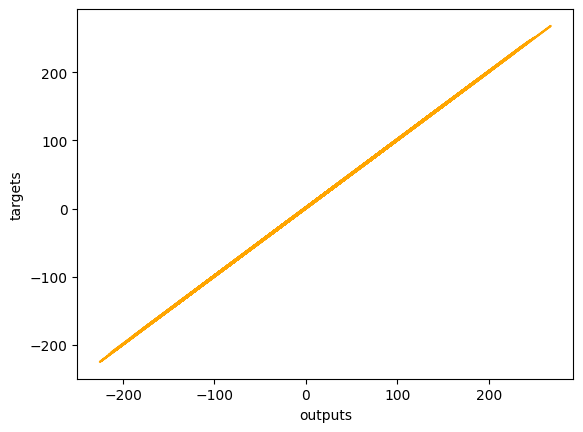

In [16]:
plt.plot(outputs, targets, color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()